# Sentinel-1 GRD Product: Radiometric Calibration

- **Goal:** Convert the raw SAR pixel values into physically meaningful radar backscatter (σ⁰, γ⁰, or β⁰).
- **Why:** removes effects caused by sensor settings, geometry, and acquisition mode; comparable across time, comparable between images.

### How
- Calibration factors found in quality/calibration 
- Follow [Radiometric Calibration Docs](https://sentinels.copernicus.eu/documents/247904/685163/S1-Radiometric-Calibration-V1.0.pdf) Section 4

In [1]:
import numpy as np
import xarray as xr
from xcube.core.store import new_data_store
from xcube_resampling import rectify_dataset, affine_transform_dataset
from xcube_resampling.gridmapping import GridMapping
from dask.distributed import Client, LocalCluster

xr.set_options(display_expand_attrs=False)

In [2]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    memory_limit="4GB",
    dashboard_address="8787",
)
client = Client(cluster)
client.dashboard_link

'http://127.0.0.1:8787/status'

In [3]:
path = (
    "data/S1A_IW_GRDH_1SDV_20251209T165439_20251209T165508_062241_07CAD4_3B2A.zarr"
)

In [4]:
%%time
dt = xr.open_datatree(path, engine="zarr", chunks={})
dt

CPU times: user 193 ms, sys: 16.1 ms, total: 210 ms
Wall time: 203 ms


<xarray.DataTree>
Group: /
│   Attributes: (2)
├── Group: /S01SIWGRD_20251209T165439_0029_A356_3B2A_07CAD4_VH
│   │   Attributes: (3)
│   ├── Group: /S01SIWGRD_20251209T165439_0029_A356_3B2A_07CAD4_VH/conditions
│   │   ├── Group: /S01SIWGRD_20251209T165439_0029_A356_3B2A_07CAD4_VH/conditions/antenna_pattern
│   │   │       Dimensions:              (azimuth_time: 32, count: 718)
│   │   │       Coordinates:
│   │   │         * azimuth_time         (azimuth_time) datetime64[ns] 256B 2025-12-09T16:54:...
│   │   │         * count                (count) int64 6kB 0 1 2 3 4 5 ... 713 714 715 716 717
│   │   │       Data variables:
│   │   │           elevation_angle      (azimuth_time, count) float32 92kB dask.array<chunksize=(32, 718), meta=np.ndarray>
│   │   │           incidence_angle      (azimuth_time, count) float32 92kB dask.array<chunksize=(32, 718), meta=np.ndarray>
│   │   │           roll                 (azimuth_time) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
│   │   │           slant_range_time_ap  (azimuth_time, count) float64 184kB dask.array<chunksize=(32, 718), meta=np.ndarray>
│   │   │           swath                (azimuth_time) <U3 384B dask.array<chunksize=(32,), meta=np.ndarray>
│   │   │           terrain_height       (azimuth_time) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20251209T165439_0029_A356_3B2A_07CAD4_VH/conditions/attitude
│   │   │       Dimensions:       (azimuth_time: 30)
│   │   │       Coordinates:
│   │   │         * azimuth_time  (azimuth_time) datetime64[ns] 240B 2025-12-09T16:54:38.8749...
│   │   │       Data variables:
│   │   │           pitch         (azimuth_time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           q0            (azimuth_time) float32 120B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           q1            (azimuth_time) float32 120B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           q2            (azimuth_time) float32 120B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           q3            (azimuth_time) float32 120B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           roll          (azimuth_time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           wx            (azimuth_time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           wy            (azimuth_time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           wz            (azimuth_time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           yaw           (azimuth_time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20251209T165439_0029_A356_3B2A_07CAD4_VH/conditions/doppler_centroid
│   │   │       Dimensions:                            (azimuth_time: 30, degree: 3)
│   │   │       Coordinates:
│   │   │         * azimuth_time                       (azimuth_time) datetime64[ns] 240B 202...
│   │   │         * degree                             (degree) int64 24B 2 1 0
│   │   │       Data variables:
│   │   │           data_dc_polynomial                 (azimuth_time, degree) float32 360B dask.array<chunksize=(30, 3), meta=np.ndarray>
│   │   │           data_dc_rms_error                  (azimuth_time) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           data_dc_rms_error_above_threshold  (azimuth_time) bool 30B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_start_time        (azimuth_time) bool 30B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_stop_time         (azimuth_time) bool 30B dask.array<chunksize=(30,), meta=np.ndarray>
│   │   │           geometry_dc_polynomial             (azimuth_time, degree) float32 360B dask.array<chunksize=(30, 3), meta=np.ndarray>
│   │   │           t0                                 (azimuth_time) float64 240

In [5]:
%%time
group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
grd

CPU times: user 7.64 ms, sys: 992 μs, total: 8.63 ms
Wall time: 6.75 ms


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 155kB 2025-12-09T16:54:39.032...
  * ground_range  (ground_range) float64 211kB 0.0 10.0 ... 2.636e+05 2.636e+05
    line          (azimuth_time) int64 155kB dask.array<chunksize=(2048,), meta=np.ndarray>
    pixel         (ground_range) int64 211kB dask.array<chunksize=(4096,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [7]:
%%time
grd = grd.assign_coords(azimuth_time=(grd.azimuth_time - grd.azimuth_time[0]) / np.timedelta64(1, "s"))
grd

CPU times: user 172 ms, sys: 30.2 ms, total: 202 ms
Wall time: 224 ms


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 10.0 ... 2.636e+05 2.636e+05
    line          (azimuth_time) int64 155kB dask.array<chunksize=(2048,), meta=np.ndarray>
    pixel         (ground_range) int64 211kB dask.array<chunksize=(4096,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 1GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [8]:
%%time
gm = GridMapping.from_coords(
    grd.ground_range,
    grd.azimuth_time,
    "EPSG:4326",
    tile_size=(grd.vv.data.chunksize[1], grd.vv.data.chunksize[0]),
)
gm

CPU times: user 807 ms, sys: 39.4 ms, total: 846 ms
Wall time: 886 ms


class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: True
* crs: EPSG:4326
* xy_res: (10, 0.00149938)
* xy_bbox: (-5, -0.00074969, 263605, 29.04081569)
* ij_bbox: (0, 0, 26361, 19369)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('ground_range', 'azimuth_time')
* size: (26361, 19369)
* tile_size: (4096, 2048)

> Note!  
> Different calibration are possible; maybe also use also `beta_nought`, `gamma`, and `dn`.

In [9]:
%%time
sigma_lut = dt[group_VH].quality.calibration.to_dataset()[["sigma_nought"]]
sigma_lut = sigma_lut.assign_coords(azimuth_time=(sigma_lut.azimuth_time - sigma_lut.azimuth_time[0]) / np.timedelta64(1, "s"))
sigma_lut = sigma_lut.isel(ground_range=slice(0, -1))
sigma_lut

CPU times: user 113 ms, sys: 8.11 ms, total: 121 ms
Wall time: 139 ms


<xarray.Dataset> Size: 93kB
Dimensions:       (azimuth_time: 32, ground_range: 659)
Coordinates:
  * azimuth_time  (azimuth_time) float64 256B 0.0 1.0 2.0 3.0 ... 29.0 30.0 31.0
  * ground_range  (ground_range) float64 5kB 0.0 7.747e+06 ... 5.098e+09
    line          (azimuth_time) uint32 128B dask.array<chunksize=(32,), meta=np.ndarray>
    pixel         (ground_range) uint32 3kB dask.array<chunksize=(659,), meta=np.ndarray>
Data variables:
    sigma_nought  (azimuth_time, ground_range) float32 84kB dask.array<chunksize=(32, 659), meta=np.ndarray>

In [10]:
%%time
source_gm = GridMapping.from_coords(sigma_lut.ground_range, sigma_lut.azimuth_time, "EPSG:4326")
source_gm

CPU times: user 208 ms, sys: 20.3 ms, total: 228 ms
Wall time: 273 ms


class: **Coords1DGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: True
* crs: EPSG:4326
* xy_res: (7747200, 1)
* xy_bbox: (-3873600, -0.5, 5101531200, 31.5)
* ij_bbox: (0, 0, 659, 32)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('ground_range', 'azimuth_time')
* size: (659, 32)
* tile_size: (659, 32)

In [11]:
%%time
sigma_lut_interp = affine_transform_dataset(
    sigma_lut,
    target_gm=gm,
    source_gm=source_gm,
)
sigma_lut_interp

CPU times: user 60 ms, sys: 7.05 ms, total: 67.1 ms
Wall time: 62.6 ms


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 10.0 ... 2.636e+05 2.636e+05
    spatial_ref   int64 8B 0
    pixel         (ground_range) int64 211kB dask.array<chunksize=(4096,), meta=np.ndarray>
    line          (azimuth_time) int64 155kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    sigma_nought  (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [12]:
%%time
sigma_0 = (grd**2) / (sigma_lut_interp.sigma_nought**2)
sigma_0

CPU times: user 25.5 ms, sys: 6.16 ms, total: 31.7 ms
Wall time: 25.2 ms


<xarray.Dataset> Size: 4GB
Dimensions:       (ground_range: 26361, azimuth_time: 19369)
Coordinates:
  * ground_range  (ground_range) float64 211kB 0.0 10.0 ... 2.636e+05 2.636e+05
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
    line          (azimuth_time) int64 155kB dask.array<chunksize=(2048,), meta=np.ndarray>
    pixel         (ground_range) int64 211kB dask.array<chunksize=(4096,), meta=np.ndarray>
    spatial_ref   int64 8B 0
Data variables:
    vh            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

In [13]:
%%time
store = new_data_store("file", root="data")

CPU times: user 51.3 ms, sys: 20.8 ms, total: 72.1 ms
Wall time: 69.8 ms


In [14]:
%%time
store.write_data(sigma_0, "sen1_radio_calib.zarr", replace=True)

CPU times: user 4.41 s, sys: 1.53 s, total: 5.93 s
Wall time: 15.6 s


'sen1_radio_calib.zarr'

In [15]:
%%time
ds = store.open_data("sen1_radio_calib.zarr")
ds

CPU times: user 28.8 ms, sys: 3.13 ms, total: 32 ms
Wall time: 27.4 ms


<xarray.Dataset> Size: 4GB
Dimensions:       (azimuth_time: 19369, ground_range: 26361)
Coordinates:
  * azimuth_time  (azimuth_time) float64 155kB 0.0 0.001499 ... 29.04 29.04
  * ground_range  (ground_range) float64 211kB 0.0 10.0 ... 2.636e+05 2.636e+05
    line          (azimuth_time) int64 155kB dask.array<chunksize=(2048,), meta=np.ndarray>
    pixel         (ground_range) int64 211kB dask.array<chunksize=(4096,), meta=np.ndarray>
    spatial_ref   int64 8B ...
Data variables:
    vh            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

CPU times: user 920 ms, sys: 115 ms, total: 1.04 s
Wall time: 1.95 s


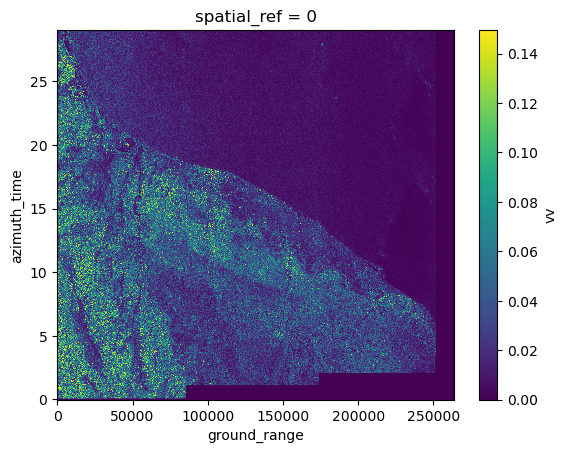

In [16]:
%%time
ds.vv[::20, ::20].plot()